# Assign cell types and create pseudobulk

+ Input: 'adata_clusters.h5ad'
+ Output: '{cell_type}_pseudobulk.tsv'
+ Next step: TMM normalisation and Covariate generation in R (perhaps incorporate here later using rpy2)

In [137]:
# This cell is labelled 'parameters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [138]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.1] 

2025-02-27 18:26:23,797 - INFO - Plate variable detected: plate1
2025-02-27 18:26:23,799 - INFO - Processing plate: plate1



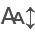

2025-02-27 18:26:23,923 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-02-27 18:26:23,924 - INFO - Parse directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-02-27 18:26:23,925 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-02-27 18:26:23,926 - INFO - Scanpy directory exists: True
2025-02-27 18:26:23,951 - INFO - Sheets directory: /Users/darren/Desktop/eQTL_study_2025/resources/sheets/
2025-02-27 18:26:23,968 - INFO - plate_dir set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/
2025-02-27 18:26:23,992 - INFO - Loading data ...
2025-02-27 18:26:24,222 - INFO - Check raw shape... 

(7340, 1724)


matrix([[1.9380656, 1.9380656, 0.       , 0.       , 0.       ,
         0.       , 0.       , 1.9380656, 0.       , 1.9380656],
        [1.6194323, 2.2083235, 2.2083235, 1.6194323, 1.6194323,
         0.       , 1.6194323, 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 2.478969 , 0.       ,
         0.       , 2.478969 , 2.478969 , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 3.6278026, 0.       , 0.       , 2.960883 ],
        [0.       , 3.748008 , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 2.6954482],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         2.9801917, 3.6476192, 0.       , 0.       , 2.9801917],
        [0.       , 2.4162781, 0.       , 2.4162781, 0.       ,
         0.       , 0.       , 3.4535446, 0.       , 3.0637722],
        [1.3588834, 1.3588834, 1.3588834, 0.       , 1.3588834,
         1.9145212, 1.3588834, 1.

In [ ]:
# Initialize the environment and get all paths and logger
logger, root_dir, sheets_dir, plate_path, scanpy_dir = initialize_env(plate)
logger.info("Loading data ...")
adata = sc.read(scanpy_dir + f'adata_clusters.h5ad')

# Pull out raw counts 
#adata.X = get_raw_counts_all_genes(adata)  # This will set adata.X to the raw counts for all genes
adata.X = adata.raw.X.copy() # Bring all genes back
#adata.X = adata.layers["counts"].copy() # Bring integer counts back
logger.info(f"Check raw shape ... \n\n{adata.shape}")
#logger.info(f"Check only int in raw ... \n\n{adata.X[:10, :10]}") 
adata.X[:10, :10].todense()

# Find overlapping samples with test Genotype data

In [140]:
logger.info("Finding overlaps ...")
overlap_file = Path(root_dir + 'resources/test_genotypes/overlapping_samples.txt')

if not overlap_file.exists():
    # Load VCF sample IDs
    with open("/Users/darren/Desktop/eQTL_study_2025/resources/test_genotypes/vcf_samples.txt", "r") as f:
        vcf_samples = set(f.read().splitlines())
    vcf_samples
    # Load snRNA-seq sample IDs (modify based on your format)
    snrna_samples = set(adata.obs["sample"].unique())  # Adjust column name if needed
    snrna_samples

    # # Find overlapping samples
    overlapping_samples = vcf_samples.intersection(snrna_samples)
    print(f"Overlapping samples: {len(overlapping_samples)} / {len(snrna_samples)}")

    # Save overlapping samples list
    with open(overlap_file, "w") as f:
        f.write("\n".join(overlapping_samples))
else:
    print("Overlapping samples file already exists")
    with open(overlap_file, "r") as f:
        overlapping_samples = set(f.read().splitlines())


2025-02-27 18:26:24,235 - INFO - Finding overlaps ...


Overlapping samples file already exists


In [141]:
len(overlapping_samples)

34

# Set cluster IDs

In [142]:
logger.info("Setting cluster IDs ...")
# Set cluster names
cluster_anns = {
    
    '0': 'RG',
    '1': 'ExN-1',
    '2': 'InN-1',
    '3': 'ExN-2',
    '4': 'InN-2',
    '5': 'Endo-Peri',
    '6': 'MG',
    '7': 'Mig-N',
}

custom_palette = {
    'RG': '#FF5959',
    'ExN-1': '#00B6EB',
    'InN-1': '#3CBB75FF',
    'ExN-2': '#CEE5FD',
    'InN-2': '#95D840FF',
    'Endo-Peri': '#B200ED',
    'MG': '#F58231',
    'Mig-N': '#2FF18B'
}

# Create a new column in adata.obs with cell type names
adata.obs['cell_type'] = adata.obs['leiden_harmony_0.1'].map(cluster_anns)

# Check the new column
print(adata.obs[['leiden_harmony_0.1', 'cell_type']].head())

2025-02-27 18:26:24,262 - INFO - Setting cluster IDs ...


                     leiden_harmony_0.1 cell_type
plate1_24_66_46__s9                   0        RG
plate1_08_15_26__s12                  0        RG
plate1_24_52_90__s13                  0        RG
plate1_15_28_57__s4                   0        RG
plate1_45_49_28__s8                   2     InN-1


In [143]:
adata.obs['cell_type'].value_counts()

cell_type
RG       3605
ExN-1    1821
InN-1    1652
ExN-2     262
Name: count, dtype: int64

# Manually generate Pseudobulk

+ I had issues trying to generate pseudobulk with [decoupler](https://github.com/saezlab/decoupler-py/issues/166) so left that method for now

In [144]:
logger.info("Generating psudobulk ...")
pseudblk_dfs = {}

for cell_type in adata.obs.cell_type.unique():
    print(f"Processing cell type: {cell_type}")
    
    # Subset the data for the current cell type (create a copy)
    cell_subset = adata[adata.obs['cell_type'] == cell_type].copy()
    
    # Initialize an empty list to store pseudobulk objects
    combined_pseudobulk_lst = []

    # Loop through unique samples
    for sample in cell_subset.obs['sample'].unique():

        # Remove samples not in the overlapping set
        if sample not in overlapping_samples:  
            continue

        samp_cell_subset = cell_subset[cell_subset.obs['sample'] == sample].copy()

        # Extract the raw counts
        counts_matrix = samp_cell_subset.X
        
        # Ensure counts are stored as integers
        print(f"Max count value (should be integer): {counts_matrix.max()}")
        
        # Sum counts across cells in the sample
        pseudobulk_counts = counts_matrix.sum(axis=0).A1 if hasattr(counts_matrix, "A1") else counts_matrix.sum(axis=0)
        
        # Create an AnnData object with summed counts
        samp_adata = sc.AnnData(X=pseudobulk_counts.reshape(1, -1), var=samp_cell_subset.var)
        samp_adata.obs_names = [sample]

        # Append to the list
        combined_pseudobulk_lst.append(samp_adata)

    # Combine all samples into one AnnData object
    pseudobulk_adata = sc.concat(combined_pseudobulk_lst, join="outer")

    # Convert pseudobulk_adata to a DataFrame for the current cell type
    pseudobulk_df = pd.DataFrame(pseudobulk_adata.X, columns=pseudobulk_adata.var_names, index=pseudobulk_adata.obs_names)
    print(f"pseudobulk_df dims: {pseudobulk_df.shape}")

    # Save the DataFrame to the dictionary
    pseudblk_dfs[cell_type] = pseudobulk_df

    # Save the TMM-corrected pseudobulk data for this cell type to a CSV file
    pseudobulk_df.to_csv(os.path.join(scanpy_dir, f'pseudobulk/{cell_type}_pseudobulk.csv'))

2025-02-27 18:26:24,370 - INFO - Generating psudobulk ...


Processing cell type: RG
Max count value (should be integer): 5.812138557434082
Max count value (should be integer): 5.788339138031006
Max count value (should be integer): 6.302194118499756
Max count value (should be integer): 5.537381649017334
Max count value (should be integer): 5.7050299644470215
Max count value (should be integer): 5.645228862762451
Max count value (should be integer): 5.793081760406494
Max count value (should be integer): 5.907712936401367
Max count value (should be integer): 5.780486106872559
Max count value (should be integer): 5.683311462402344
Max count value (should be integer): 5.957685947418213
Max count value (should be integer): 5.752406120300293
Max count value (should be integer): 5.260810852050781
Max count value (should be integer): 5.977262020111084
Max count value (should be integer): 5.860007286071777
Max count value (should be integer): 5.710618495941162
Max count value (should be integer): 5.931082725524902
Max count value (should be integer): 5.

In [145]:
for df in pseudblk_dfs:
    print(pseudblk_dfs[df].shape)

(34, 1724)
(27, 1724)
(33, 1724)
(6, 1724)


In [146]:
# Determining Covariates : Need to do this in R
# Extract PC loadings
# pc_df = pd.DataFrame(adata.obsm["X_pca"], index=adata.obs.index)

# # Check correlation with potential covariates
# covariates = ["sublibrary", "plate"]  # Modify based on your data
# corr_df = pc_df.join(adata.obs[covariates])
# corr_df = pd.get_dummies(corr_df, columns=["plate"], drop_first=True)
# correlations = corr_df.corr()
# print(correlations)

# plt.figure(figsize=(10, 8))

# # Generate heatmap
# sns.heatmap(correlations, cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
# plt.title("Correlation Matrix Heatmap")
# plt.show()



2025-02-27 18:26:25,569 - INFO - Creating UMAP with cell types ...


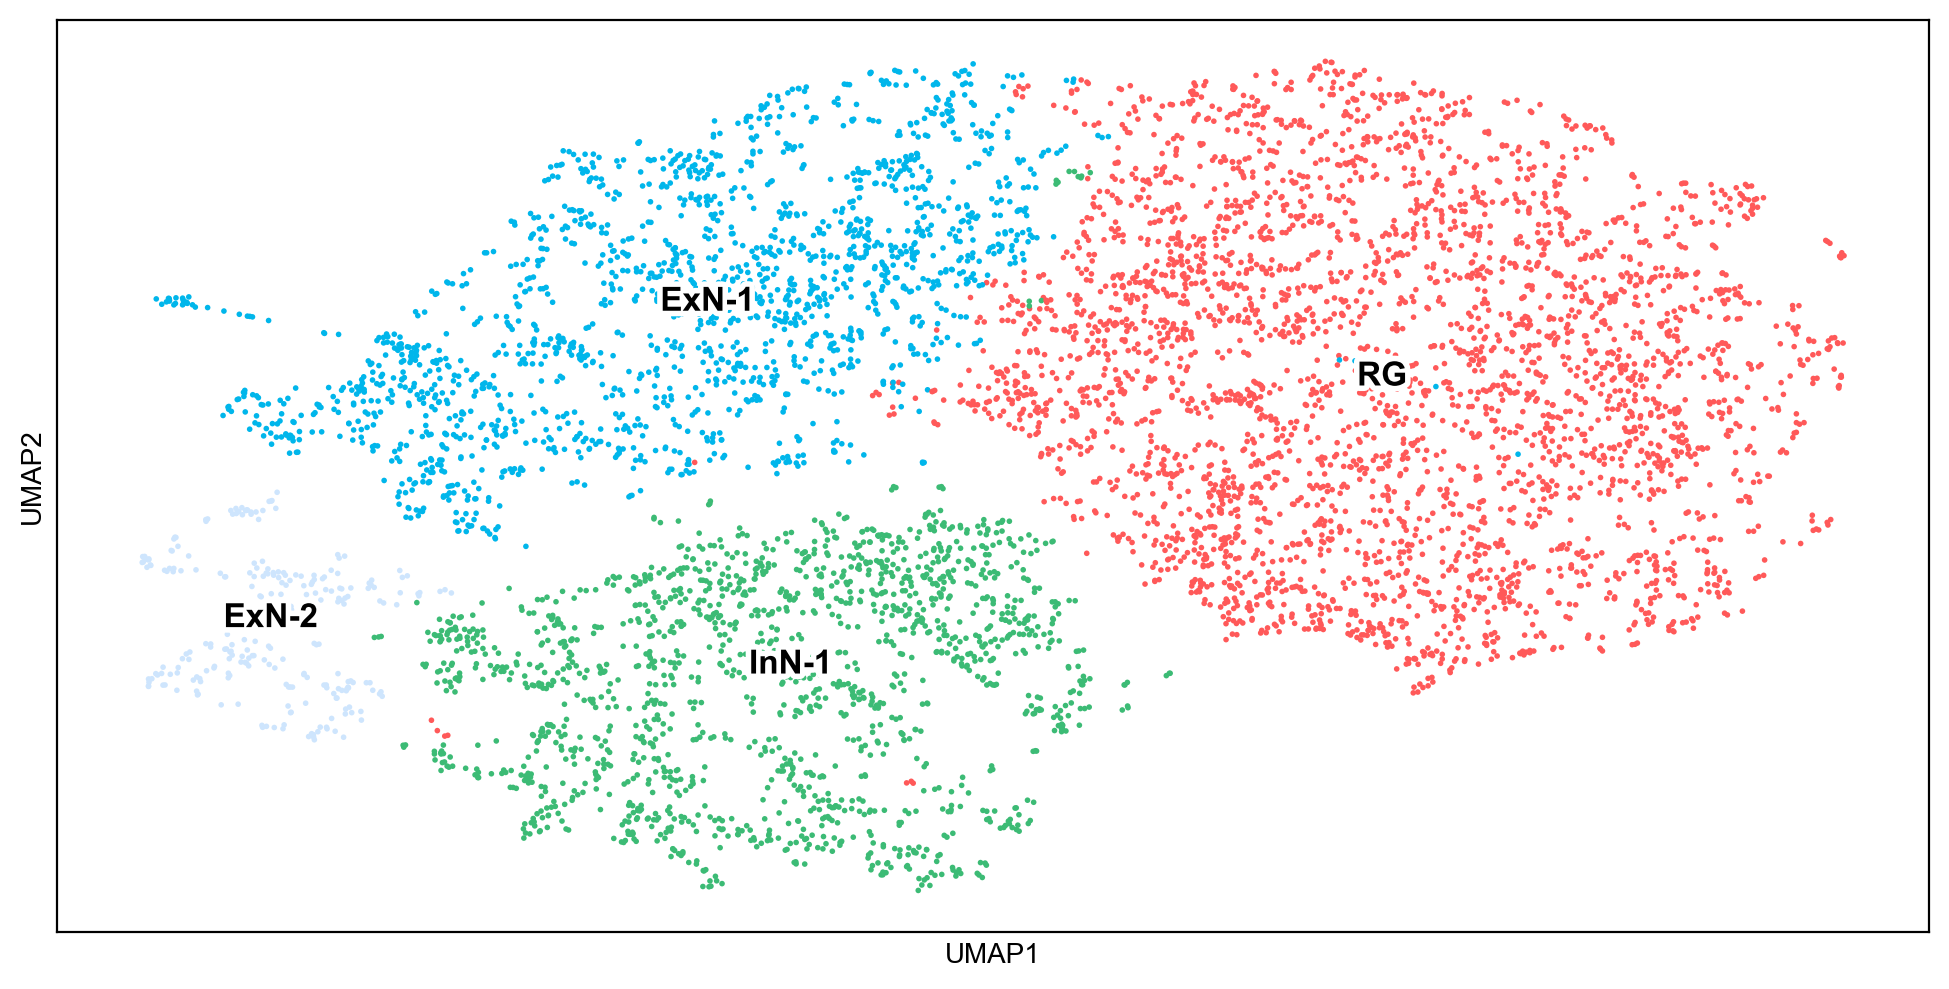

In [147]:
# Assign colors to Scanpy (must match the order of unique cell types)
logger.info(f"Creating UMAP with cell types ...")
sc.pl.umap(
        adata,
        color='cell_type',
#        add_outline=True,
        legend_loc="on data",
        legend_fontsize=12,
        legend_fontoutline=4,
        title='',
        palette=custom_palette,
    )

2025-02-27 18:26:25,810 - INFO - Checking DEx genes ... 


ranking genes
    consider 'leiden_harmony_0.1' groups:
    with sizes: [3605 1821 1652  262]
    finished: added to `.uns['t-test_ov']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


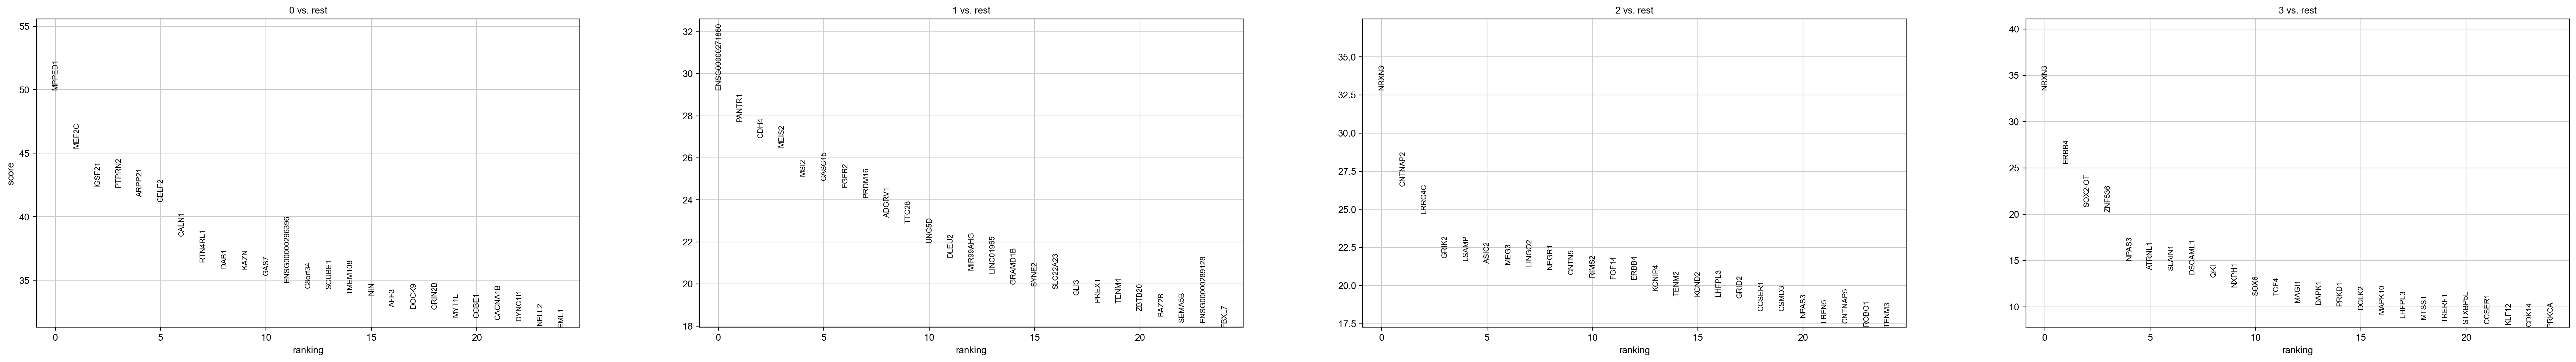

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden_harmony_0.1']`


2025-02-27 18:26:27,623 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-27 18:26:27,634 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-27 18:26:27,636 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-27 18:26:27,708 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-27 18:26:27,718 - INFO - Using categorical units to plot a list of strings that are all parsable as 

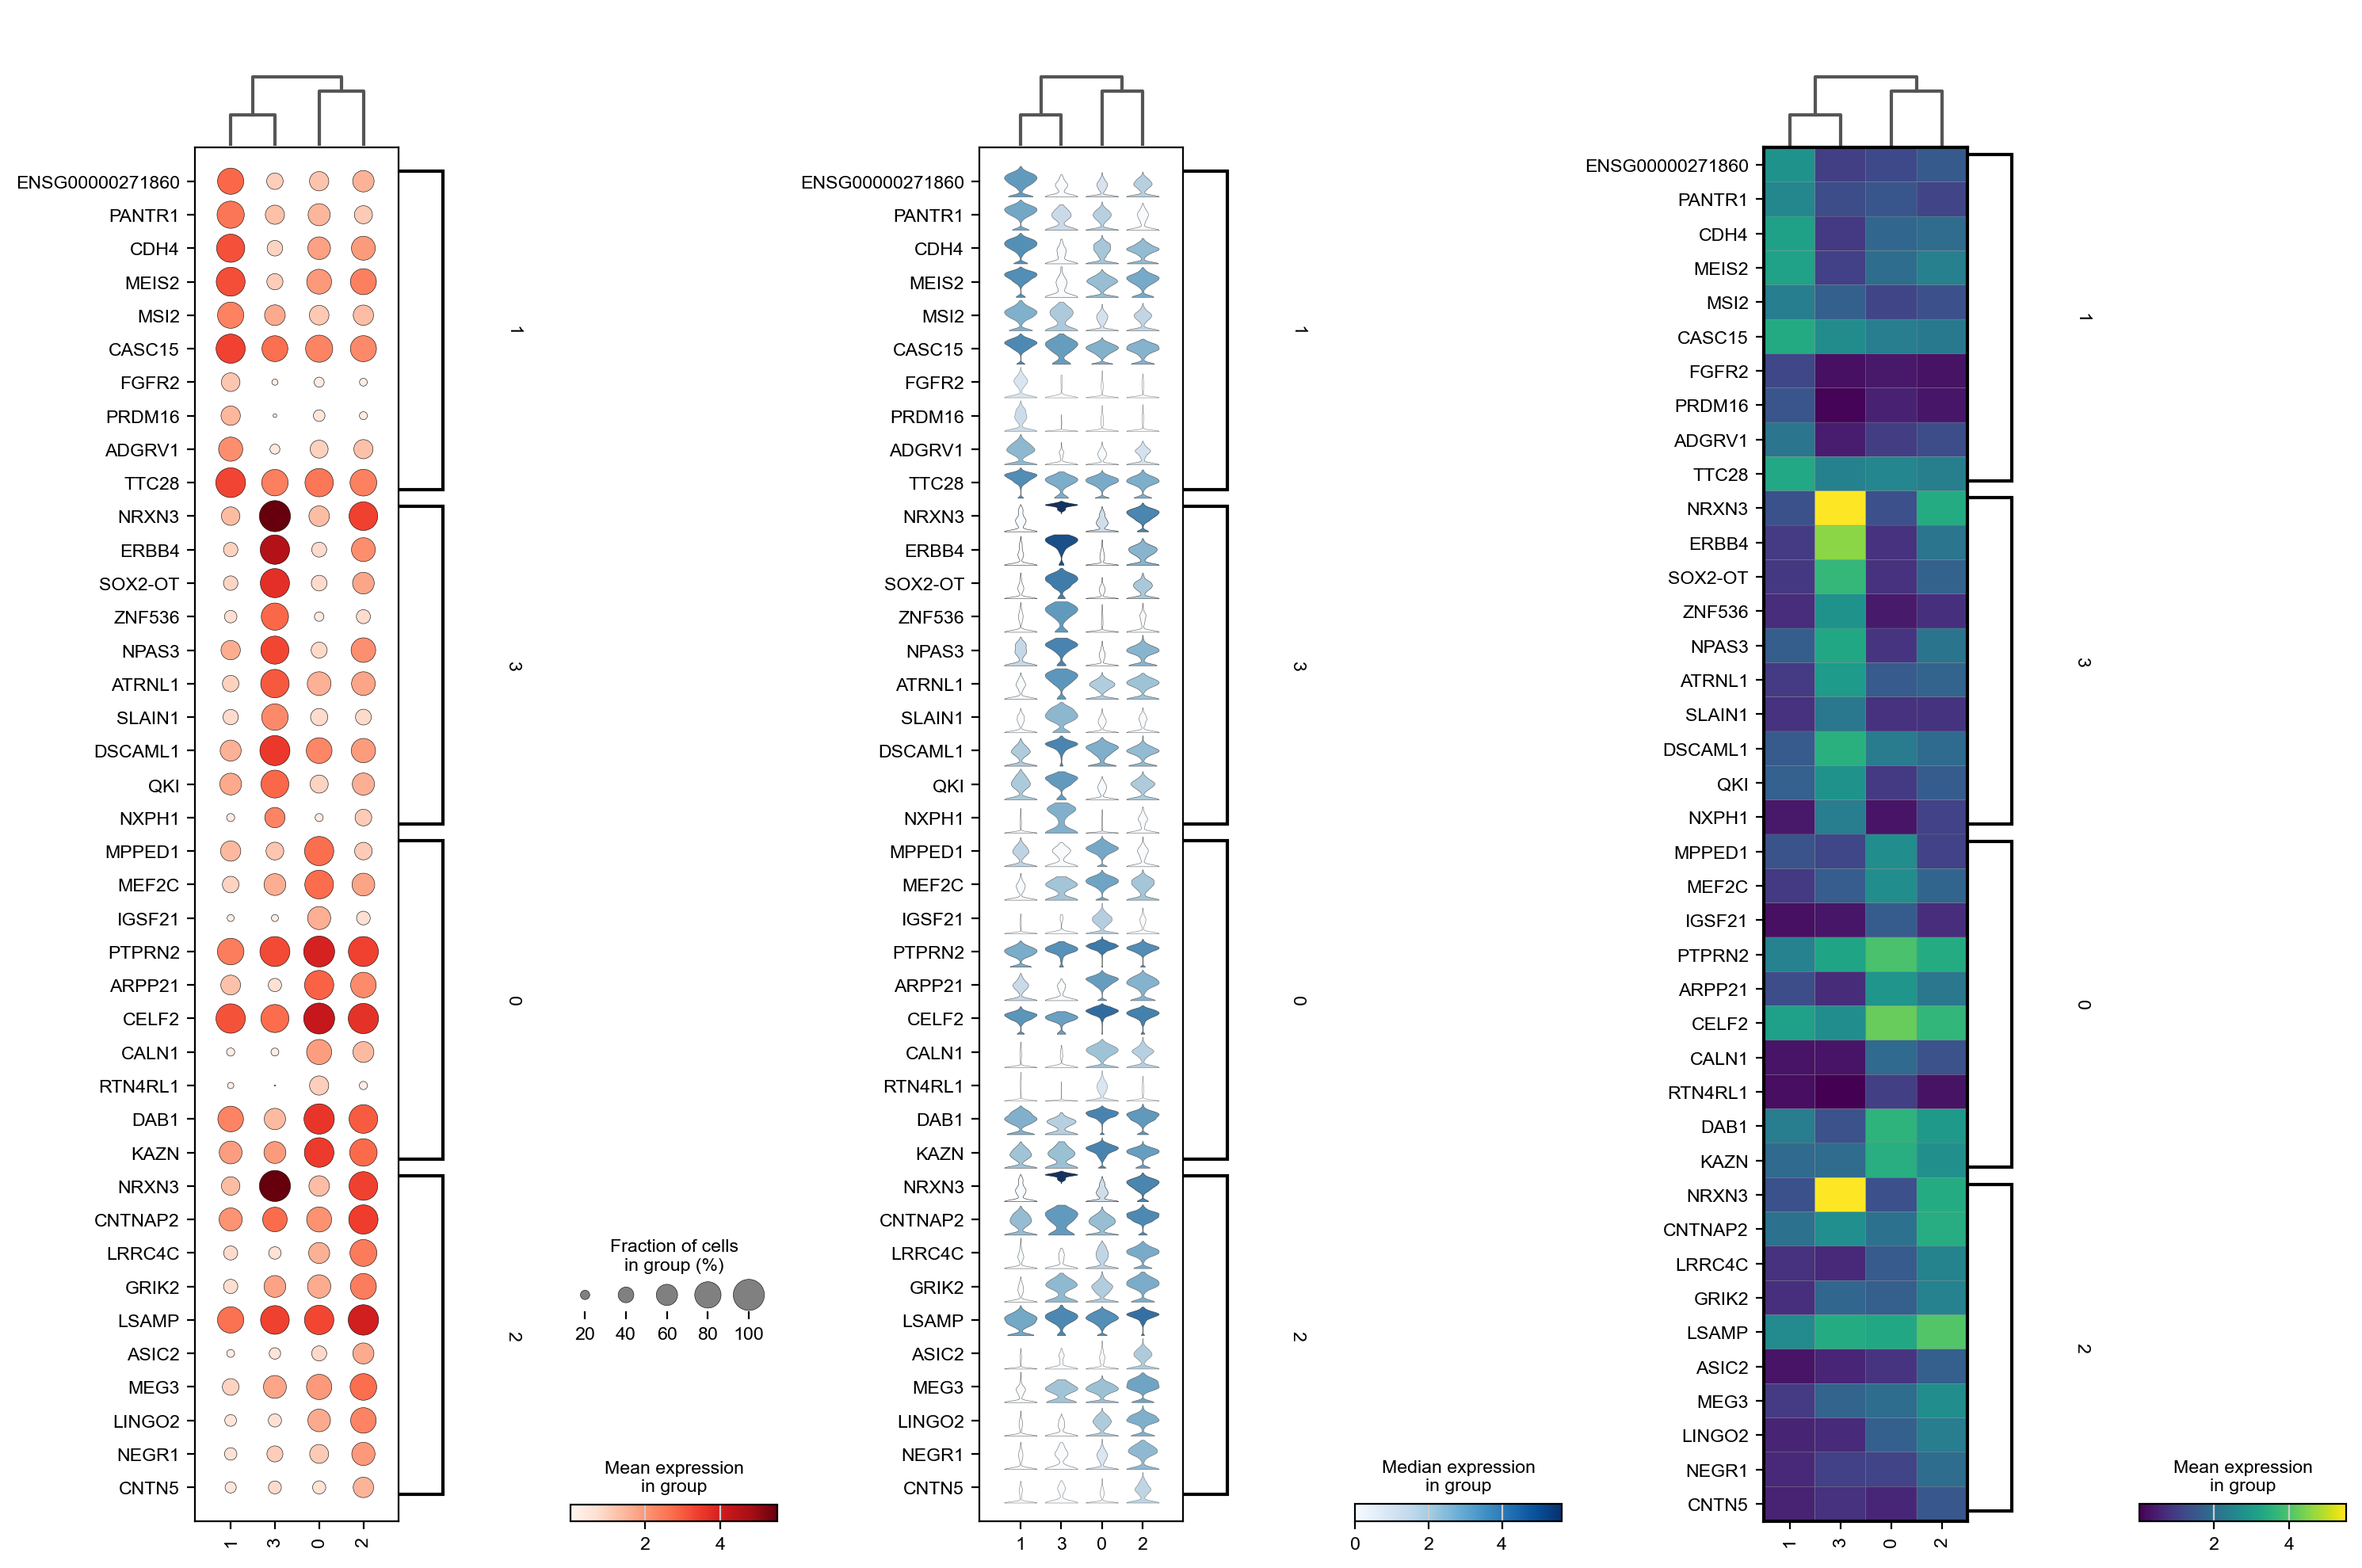

In [148]:
logger.info(f"Checking DEx genes ... ")
sc.tl.rank_genes_groups(adata, 'leiden_harmony_0.1', method='t-test_overestim_var', key_added = "t-test_ov")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "t-test_ov")
plot_rank_genes_groups(adata, n_genes=10, key="t-test_ov", groupby="leiden_harmony_0.1")

In [149]:
# Final Markers
# marker_genes_dict = {
#     'RG': ['GLI3', 'SLC1A3'],
#     'ExN-1': ['SATB2'],
#     'InN-1': ['NRXN3', 'CNTNAP2'],
#     'ExN-2': ['GRIK3', 'GAS7'],
#     'InN-2': ['GAD1', 'SOX6', 'DLX6-AS1', 'ERBB4'],
#     'Endo-Peri': ['FN1', 'COL4A1'],
#     'MG': ['C3', 'INPP5D', 'CSF1R'],
#     'Mig-N': ['EBF3']
# }

# sc.pl.dotplot(adata, marker_genes_dict, "cell_type", dendrogram=True)
# ax = sc.pl.stacked_violin(
#     adata, marker_genes_dict, groupby="cell_type", swap_axes=True, dendrogram=True
# )
# sc.pl.matrixplot(
#     adata,
#     marker_genes_dict,
#     "cell_type",
#     dendrogram=True,
#     cmap="Blues",
#     standard_scale="var",
#     colorbar_title="column scaled\nexpression",
# )

In [150]:
# scale and store results in layer
# adata.layers["scaled"] = sc.pp.scale(adata, copy=True).X
# sc.pl.matrixplot(
#     adata,
#     marker_genes_dict,
#     "clusters",
#     dendrogram=True,
#     colorbar_title="mean z-score",
#     layer="scaled",
#     vmin=-2,
#     vmax=2,
#     cmap="RdBu_r",
# )

In [151]:
# Code fo eQTL plot
# 
# # import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Generate dummy data
# np.random.seed(42)
# n_samples = 100
# genotypes = np.random.choice([0, 1, 2], size=n_samples, p=[0.3, 0.4, 0.3])  # Genotypes 0,1,2
# expression = np.random.normal(loc=10, scale=2, size=n_samples) + genotypes * 1.5  # Gene expression shifts by genotype

# # Create DataFrame
# df = pd.DataFrame({'Genotype': genotypes, 'GeneX Expression': expression})

# # Convert genotype to categorical (optional: map numeric to alleles like 'AA', 'AG', 'GG')
# df["Genotype"] = df["Genotype"].astype(str)  # Convert to string for categorical plotting

# # Plot
# plt.figure(figsize=(6, 5))
# sns.boxplot(x="Genotype", y="GeneX Expression", data=df, width=0.6, showfliers=False,
#             boxprops={'facecolor': 'lightblue'})  # Set box color to light blue
# sns.stripplot(x="Genotype", y="GeneX Expression", data=df, jitter=True, color='black', alpha=0.3)

# # Set the x-axis order to 0, 1, 2
# sns.boxplot(x="Genotype", y="GeneX Expression", data=df, width=0.6, showfliers=False, 
#             boxprops={'facecolor': 'lightblue'}, order=['0', '1', '2'])

# # Labels
# plt.xlabel("Genotype")
# plt.ylabel("GeneX Expression")
# plt.title("eQTL Plot for GeneX")

# plt.show()

